In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

**1. Importing Data**

As in the PyTorch script, the Fashion-MNIST dataset will also be used in this implementation.

In [3]:
(x_train, y_train), (x_test, y_test) = (
    tf.keras.datasets.fashion_mnist.load_data()
)

**2. Exploratory Data Analysis**

In [4]:
print(f"The length of train dataset: {len(x_train)}")
print(f"The length of train dataset: {len(y_train)}")
print(f"The length of train dataset: {len(x_test)}")
print(f"The length of train dataset: {len(y_test)}")

The length of train dataset: 60000
The length of train dataset: 60000
The length of train dataset: 10000
The length of train dataset: 10000


In [5]:
image = x_train[0]
image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [6]:
print(f"The shape of image is: {image.shape}")

The shape of image is: (28, 28)


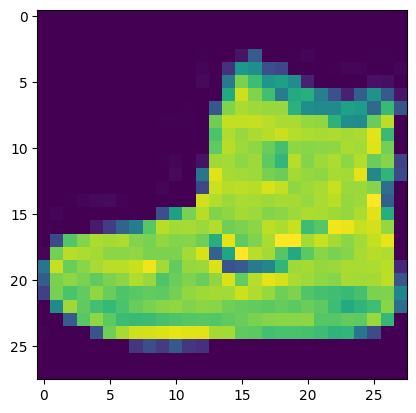

In [7]:
plt.imshow(image)

**3. Preprocessing Data**

3.1 Normalize dataset

In [8]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

3.2 Add channel dimension

In [9]:
# Add channel dimension
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

**4. Building model**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

**5. Training model**

In [13]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9339 - loss: 0.1754 - val_accuracy: 0.9132 - val_loss: 0.2429
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.9467 - loss: 0.1481 - val_accuracy: 0.9137 - val_loss: 0.2574
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 63s 36ms/step - accuracy: 0.9505 - loss: 0.1292 - val_accuracy: 0.9120 - val_loss: 0.2565
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 26ms/step - accuracy: 0.9556 - loss: 0.1177 - val_accuracy: 0.9060 - val_loss: 0.2712
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.9609 - loss: 0.1043 - val_accuracy: 0.9142 - val_loss: 0.2686


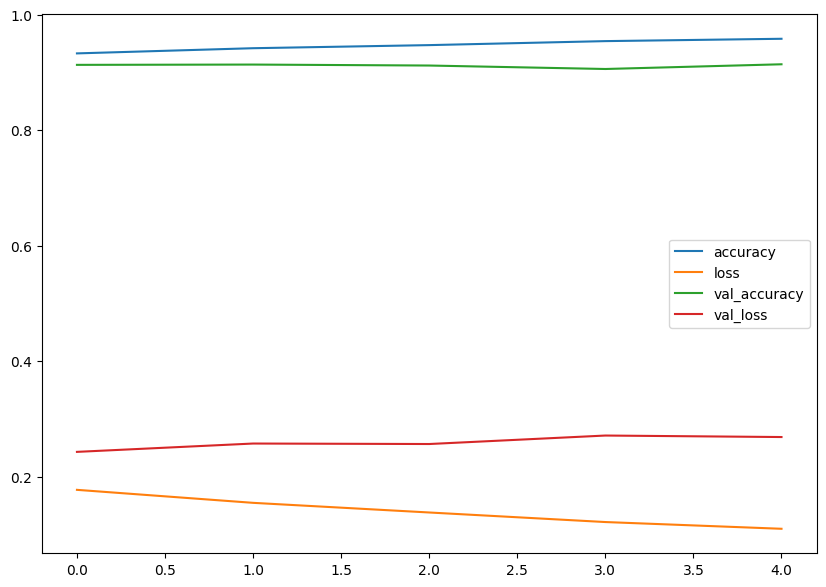

In [15]:
pd.DataFrame(history.history).plot(figsize=(10, 7));

**6. Evaluate**

In [12]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print(f"Test Accuracy: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9030 - loss: 0.2680
Test Accuracy: 90.73%
